# Dendrograma para o Dataset Adult (Agglomerative)

Este notebook permite analisar o número ideal de clusters para o dataset Adult utilizando o dendrograma do Agglomerative Clustering.

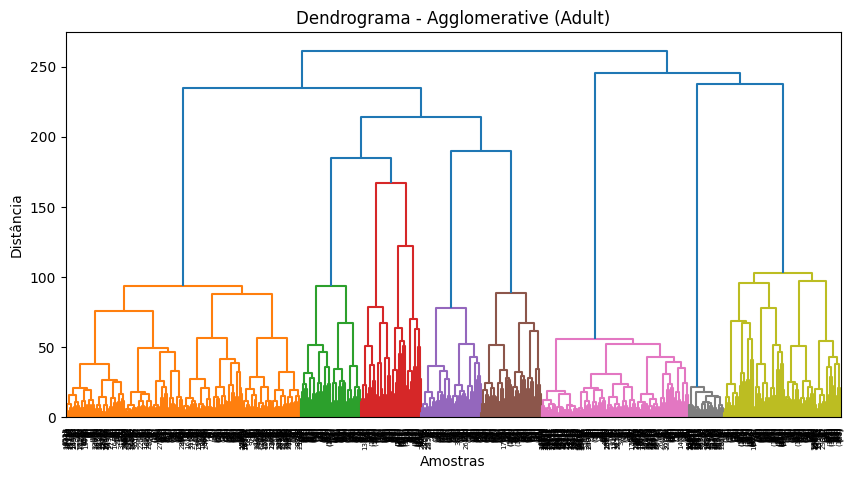

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage

# Carregamento e pré-processamento do dataset Adult
adult_df = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df = adult_df.dropna()
for col in adult_df.select_dtypes(include='object').columns:
    adult_df[col] = LabelEncoder().fit_transform(adult_df[col].astype(str))
X = adult_df.drop('income', axis=1).values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Dendrograma
plt.figure(figsize=(10, 5))
linked = linkage(X, method='ward')
dendrogram(linked, truncate_mode='level', p=10)
plt.title('Dendrograma - Agglomerative (Adult)')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.savefig('img/agglo_adult_dendrogram.png')
plt.show()